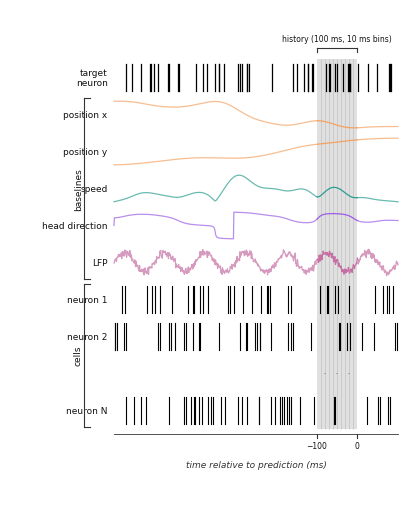

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.ndimage import gaussian_filter1d
import os

out_dir = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'

# ── Time layout ────────────────────────────────────────────────────────────────
PRE_MS   = 500
HIST_MS  = 100
POST_MS  = 100
TOTAL_MS = PRE_MS + HIST_MS + POST_MS   # 700 ms
N_BINS   = 10   # 10 ms per bin

# ── Figure x/y coords ─────────────────────────────────────────────────────────
TX0, TX1 = 0.26, 0.97
TW       = TX1 - TX0
MY0, MY1 = 0.16, 0.90
MH       = MY1 - MY0

def ms_to_x(ms): return TX0 + ms / TOTAL_MS * TW

HX0 = ms_to_x(PRE_MS)
HX1 = ms_to_x(PRE_MS + HIST_MS)
HW  = HX1 - HX0
BW  = HW / N_BINS

# ── Colors ─────────────────────────────────────────────────────────────────────
MATRIX_BG  = '#e0e0e0'
DIVIDER_C  = '#aaaaaa'
SPIKE_COL  = '#000000'
LABEL_COL  = '#111111'
ANNO_COL   = '#333333'

VAR_COLORS = {'pos': '#f4a261', 'speed': '#2a9d8f', 'hd': '#9b5de5', 'lfp': '#c56fa4'}

# ── Row definitions ────────────────────────────────────────────────────────────
ROW_DEFS = [
    dict(label='target\nneuron', sig='spikes_tgt'),
    dict(label='position x',     sig='continuous', key='pos_x',  color=VAR_COLORS['pos']),
    dict(label='position y',     sig='continuous', key='pos_y',  color=VAR_COLORS['pos']),
    dict(label='speed',          sig='continuous', key='speed',  color=VAR_COLORS['speed']),
    dict(label='head direction', sig='continuous', key='hd',     color=VAR_COLORS['hd']),
    dict(label='LFP',            sig='continuous', key='lfp',    color=VAR_COLORS['lfp']),
    dict(label='neuron 1',       sig='spikes', seed=1),
    dict(label='neuron 2',       sig='spikes', seed=7),
    dict(label='',               sig='dots'),
    dict(label='neuron N',       sig='spikes', seed=99),
]
N_ROWS = len(ROW_DEFS)
ROW_H  = MH / N_ROWS
rt = lambda r: MY1 - r * ROW_H
rb = lambda r: MY1 - (r + 1) * ROW_H
ry = lambda r: MY1 - (r + 0.5) * ROW_H

# ── Generate signals (1 sample per ms) ────────────────────────────────────────
N_T = TOTAL_MS

def norm11(x):
    mn, mx = x.min(), x.max()
    return 2*(x - mn)/(mx - mn) - 1 if mx > mn else np.zeros_like(x)

rng_traj = np.random.default_rng(12345)
raw_x = np.cumsum(rng_traj.normal(0, 1, N_T))
raw_y = np.cumsum(rng_traj.normal(0, 1, N_T))
pos_x = norm11(gaussian_filter1d(raw_x, sigma=40))
pos_y = norm11(gaussian_filter1d(raw_y, sigma=40))

dx = np.diff(pos_x, prepend=pos_x[0])
dy = np.diff(pos_y, prepend=pos_y[0])
speed = norm11(np.sqrt(dx**2 + dy**2))
hd    = norm11(np.arctan2(dy, dx))

# LFP: 10 Hz theta → 7 cycles over 700 ms; exactly 1 cycle within the 100 ms history
t_sec = np.linspace(0, TOTAL_MS / 1000, N_T)
lfp = np.sin(2 * np.pi * 10.0 * t_sec) + rng_traj.normal(0, 0.20, N_T)
lfp = norm11(lfp)

signals = dict(pos_x=pos_x, pos_y=pos_y, speed=speed, hd=hd, lfp=lfp)
xs_plot = np.linspace(TX0, TX1, N_T)

# ── Spike trains ───────────────────────────────────────────────────────────────
def gen_spikes_ms(seed, rate_hz):
    rng = np.random.default_rng(seed)
    n   = max(rng.poisson(rate_hz * TOTAL_MS / 1000), 1)
    return np.sort(rng.uniform(0, TOTAL_MS, n))

tgt_spikes_ms  = gen_spikes_ms(42,  rate_hz=60)
cell_spikes_ms = {
    6: gen_spikes_ms(1,  rate_hz=50),
    7: gen_spikes_ms(7,  rate_hz=45),
    9: gen_spikes_ms(99, rate_hz=55),
}

# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(4, 5))
ax  = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# History window highlight (no row dividers drawn)
ax.add_patch(Rectangle((HX0, MY0), HW, MH,
                        facecolor=MATRIX_BG, edgecolor='none', zorder=1))

# Vertical bin dividers within history only
for b in range(1, N_BINS):
    x = HX0 + b * BW
    ax.plot([x, x], [MY0, MY1], color=DIVIDER_C, lw=0.4, alpha=0.7, zorder=3)

# ── Draw each row ──────────────────────────────────────────────────────────────
for r, row in enumerate(ROW_DEFS):
    yc  = ry(r)
    amp = ROW_H * 0.36

    if row['sig'] == 'spikes_tgt':
        for t_ms in tgt_spikes_ms:
            x = ms_to_x(t_ms)
            ax.plot([x, x], [yc - amp, yc + amp], color=SPIKE_COL, lw=0.9, zorder=5)

    elif row['sig'] == 'continuous':
        arr = signals[row['key']]
        col = row['color']
        ys  = yc + amp * arr
        m_pre  = xs_plot <= HX0
        m_hist = (xs_plot >= HX0) & (xs_plot <= HX1)
        m_post = xs_plot >= HX1
        ax.plot(xs_plot[m_pre],  ys[m_pre],  color=col, lw=0.9, alpha=0.7, zorder=4)
        ax.plot(xs_plot[m_hist], ys[m_hist], color=col, lw=0.9, zorder=4)
        ax.plot(xs_plot[m_post], ys[m_post], color=col, lw=0.9, alpha=0.7, zorder=4)

    elif row['sig'] == 'spikes':
        for t_ms in cell_spikes_ms[r]:
            x = ms_to_x(t_ms)
            ax.plot([x, x], [yc - amp, yc + amp], color=SPIKE_COL, lw=0.8, zorder=5)

    elif row['sig'] == 'dots':
        ax.text((HX0 + HX1) / 2, yc, '·  ·  ·',
                ha='center', va='center', fontsize=9, color='#888888', zorder=5)

    if row['label']:
        ax.text(TX0 - 0.016, yc, row['label'],
                ha='right', va='center', fontsize=6.5, color=LABEL_COL)

# ── Left group brackets ────────────────────────────────────────────────────────
def draw_bracket(ax, x_bar, y_top, y_bot, label):
    xw  = x_bar + 0.015
    ym  = (y_top + y_bot) / 2
    pad = 0.005
    ax.plot([x_bar, x_bar], [y_bot + pad, y_top - pad], color=ANNO_COL, lw=0.8, zorder=6)
    ax.plot([x_bar, xw],    [y_top - pad, y_top - pad], color=ANNO_COL, lw=0.8, zorder=6)
    ax.plot([x_bar, xw],    [y_bot + pad, y_bot + pad], color=ANNO_COL, lw=0.8, zorder=6)
    ax.text(x_bar - 0.014, ym, label,
            ha='center', va='center', fontsize=6.5, color=LABEL_COL, rotation=90)

BRACKET_X = TX0 - 0.075
draw_bracket(ax, BRACKET_X, rt(1), rb(5), 'baselines')
draw_bracket(ax, BRACKET_X, rt(6), rb(9), 'cells')

# ── Time axis ──────────────────────────────────────────────────────────────────
AX_Y = MY0 - 0.010
ax.plot([TX0, TX1], [AX_Y, AX_Y], color=ANNO_COL, lw=0.6)

for ms, lbl in [(PRE_MS, '−100'), (PRE_MS + HIST_MS, '0')]:
    x = ms_to_x(ms)
    ax.plot([x, x], [AX_Y, AX_Y - 0.007], color=ANNO_COL, lw=0.8)
    ax.text(x, AX_Y - 0.014, lbl, ha='center', va='top', fontsize=5.5, color=LABEL_COL)

ax.text((TX0 + TX1) / 2, AX_Y - 0.052,
        'time relative to prediction (ms)',
        ha='center', va='top', fontsize=6.5, fontstyle='italic', color=ANNO_COL)

# ── History annotation ─────────────────────────────────────────────────────────
hy = MY1 + 0.022
ax.plot([HX0, HX1], [hy,         hy], color=ANNO_COL, lw=0.8)
ax.plot([HX0, HX0], [hy - 0.008, hy], color=ANNO_COL, lw=0.8)
ax.plot([HX1, HX1], [hy - 0.008, hy], color=ANNO_COL, lw=0.8)
ax.text((HX0 + HX1) / 2, hy + 0.009,
        'history (100 ms, 10 ms bins)',
        ha='center', va='bottom', fontsize=5.5, color=LABEL_COL)

fig.savefig(os.path.join(out_dir, 'xgboost_model_schematic.pdf'), bbox_inches='tight', dpi=300)
plt.show()

## Suggested cells for model comparison

From `Figure4_v7_ratemap_reconstruction.ipynb`. Cell M25 D20 c129 is used in the combined figure below (largest ΔpR² from adding GC cells).

| Mouse | Day | Cell | pos pR² | full\_beh pR² | pos+10GC pR² | Notes |
|-------|-----|------|---------|--------------|-------------|-------|
| 25 | 21 | 108 | 0.284 | 0.397 | 0.315 | Best position encoding |
| 25 | 18 | 7 | 0.209 | 0.295 | — | Runner-up by pos pR² |
| **25** | **20** | **129** | **0.215** | **0.215** | **0.368** | **Used here — largest ΔpR² from GC cells** |
| 25 | 24 | 112 | 0.192 | 0.196 | 0.221 | Almost entirely position-explained |
| 21 | 23 | 277 | 0.172 | 0.295 | — | Strong HD conjunction |

In [2]:
import sys, warnings
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pynapple as nap
from spatial_manifolds.detect_grids import (
    compute_of_tcs, classify_cells_both_sessions, get_theta_trace, time_bs
)
from spatial_manifolds.mlencoding import MLencoding

MOUSE = 25; DAY = 20; TARGET_ID = 129; SESSION = 'OF1'; N_COV = 10
source_path = '/Users/harryclark/Downloads/COHORT12/'

print(f'Loading {SESSION} data for M{MOUSE} D{DAY}…')
tcs_raw, tcs_time, beh_OF, clusters_OF, ep = compute_of_tcs(
    MOUSE, DAY, apply_zscore=False, apply_guassian_filter=False,
    fill_nans_from_neighbors=True, source_path=source_path, session=SESSION, optimal_shift=0
)

last_t = clusters_OF[clusters_OF.index[0]].count(bin_size=time_bs, time_units='ms').index[-1]
ep2    = nap.IntervalSet(start=0, end=last_t, time_units='s')

y = np.array(tcs_time[TARGET_ID])
T = len(y)

def _bin(sig):
    a = np.array(sig.bin_average(bin_size=time_bs, time_units='ms', ep=ep2))[:T]
    return pd.Series(a).ffill().bfill().to_numpy()

pos_x = _bin(beh_OF['P_x']);  pos_y = _bin(beh_OF['P_y'])
speed = _bin(beh_OF['S']);     hd    = _bin(beh_OF['H'])

try:
    theta = np.array(get_theta_trace(
        MOUSE, DAY, TARGET_ID, time_bs=50, resample_bs=time_bs,
        session_type=SESSION, source_path=source_path
    ))
    theta = theta[:T] if len(theta) >= T else np.pad(theta, (0, T - len(theta)))
except Exception as e:
    print(f'Theta unavailable ({e}) — using zeros')
    theta = np.zeros(T)

gcs, _, _ = classify_cells_both_sessions(MOUSE, DAY, percentile_threshold=95, source_path=source_path)
cov_gc_ids = [c for c in gcs['cluster_id'].values if c != TARGET_ID and c in tcs_time][:N_COV]
cov_gc_mat = np.vstack([np.array(tcs_time[c])[:T] for c in cov_gc_ids]).T
print(f'GC covariate cells ({len(cov_gc_ids)}): {cov_gc_ids}')

xgb = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                 window=time_bs, n_filters=5, max_time=1000)

MODEL_SPECS = {
    'P':               np.column_stack([pos_x, pos_y]),
    'P+S':             np.column_stack([pos_x, pos_y, speed]),
    'P+S+HD':          np.column_stack([pos_x, pos_y, speed, hd]),
    'P+S+HD+LFP':      np.column_stack([pos_x, pos_y, speed, hd, theta]),
    'P+S+HD+LFP+10GC': np.column_stack([pos_x, pos_y, speed, hd, theta, cov_gc_mat]),
    '10GC':            cov_gc_mat,
}

predictions = {};  pr2_vals = {}
for name, X in MODEL_SPECS.items():
    Y_hat, pR2      = xgb.fit_cv(X, y, verbose=0, continuous_folds=True)
    predictions[name] = np.array(Y_hat)
    pr2_vals[name]    = float(np.nanmean(pR2))
    print(f'  {name:25s}  pR² = {pr2_vals[name]:.4f}')
print('Done.')

Loading OF1 data for M25 D20…
GC covariate cells (10): [111, 120, 126, 133, 137, 140, 146, 149, 156, 159]
  P                          pR² = 0.1778
  P+S                        pR² = 0.1698
  P+S+HD                     pR² = 0.2071
  P+S+HD+LFP                 pR² = 0.2059
  P+S+HD+LFP+10GC            pR² = 0.3595
  10GC                       pR² = 0.3222
Done.


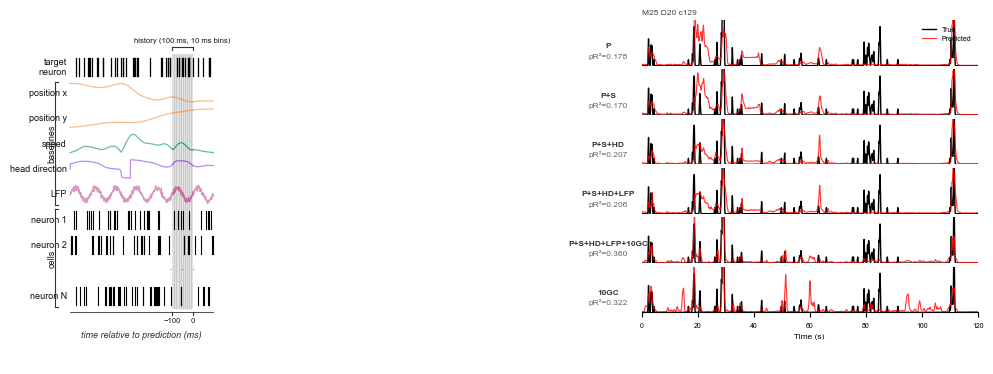

In [3]:
# ── Combined figure: schematic (left) + XGBoost prediction traces (right) ──────
# Depends on the data-loading cell above — run that cell first.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d
import os

out_dir = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'
TIME_BS = time_bs   # ms per bin (from detect_grids)

# ── Schematic synthetic signals (same seed/params as standalone schematic) ─────
PRE_MS = 500; HIST_MS = 100; POST_MS = 100; TOTAL_MS = 700; N_BINS = 10
TX0, TX1 = 0.26, 0.97;  TW = TX1 - TX0
MY0, MY1 = 0.16, 0.90;  MH = MY1 - MY0

def ms_to_x(ms): return TX0 + ms / TOTAL_MS * TW

HX0 = ms_to_x(PRE_MS);  HX1 = ms_to_x(PRE_MS + HIST_MS)
HW  = HX1 - HX0;        BW  = HW / N_BINS

SROW_DEFS = [
    dict(label='target\nneuron', sig='spikes_tgt'),
    dict(label='position x',     sig='continuous', key='pos_x',  color='#f4a261'),
    dict(label='position y',     sig='continuous', key='pos_y',  color='#f4a261'),
    dict(label='speed',          sig='continuous', key='speed',  color='#2a9d8f'),
    dict(label='head direction', sig='continuous', key='hd',     color='#9b5de5'),
    dict(label='LFP',            sig='continuous', key='lfp',    color='#c56fa4'),
    dict(label='neuron 1',       sig='spikes', seed=1),
    dict(label='neuron 2',       sig='spikes', seed=7),
    dict(label='',               sig='dots'),
    dict(label='neuron N',       sig='spikes', seed=99),
]
N_SROWS = len(SROW_DEFS)
SROW_H  = MH / N_SROWS
srt = lambda r: MY1 - r * SROW_H
srb = lambda r: MY1 - (r + 1) * SROW_H
sry = lambda r: MY1 - (r + 0.5) * SROW_H

MATRIX_BG = '#e0e0e0';  DIVIDER_C = '#aaaaaa'
SPIKE_COL = '#000000';  LABEL_COL = '#111111';  ANNO_COL = '#333333'

def norm11(x):
    mn, mx = x.min(), x.max()
    return 2*(x - mn)/(mx - mn) - 1 if mx > mn else np.zeros_like(x)

rng_sc   = np.random.default_rng(12345)
sc_raw_x = np.cumsum(rng_sc.normal(0, 1, TOTAL_MS))
sc_raw_y = np.cumsum(rng_sc.normal(0, 1, TOTAL_MS))
sc_pos_x = norm11(gaussian_filter1d(sc_raw_x, sigma=40))
sc_pos_y = norm11(gaussian_filter1d(sc_raw_y, sigma=40))
sc_dx    = np.diff(sc_pos_x, prepend=sc_pos_x[0])
sc_dy    = np.diff(sc_pos_y, prepend=sc_pos_y[0])
sc_speed = norm11(np.sqrt(sc_dx**2 + sc_dy**2))
sc_hd    = norm11(np.arctan2(sc_dy, sc_dx))
sc_t_sec = np.linspace(0, TOTAL_MS / 1000, TOTAL_MS)
sc_lfp   = norm11(np.sin(2 * np.pi * 10 * sc_t_sec) + rng_sc.normal(0, 0.20, TOTAL_MS))
sc_sigs  = dict(pos_x=sc_pos_x, pos_y=sc_pos_y, speed=sc_speed, hd=sc_hd, lfp=sc_lfp)
sc_xs    = np.linspace(TX0, TX1, TOTAL_MS)

def gen_sc_spikes(seed, rate):
    rng = np.random.default_rng(seed)
    n   = max(rng.poisson(rate * TOTAL_MS / 1000), 1)
    return np.sort(rng.uniform(0, TOTAL_MS, n))

sc_tgt   = gen_sc_spikes(42, 60)
sc_cells = {6: gen_sc_spikes(1, 50), 7: gen_sc_spikes(7, 45), 9: gen_sc_spikes(99, 55)}

# ── Smoothed prediction traces (first DISP_SECS seconds) ──────────────────────
DISP_SECS = 120
DISP_BINS = int(DISP_SECS * 1000 / TIME_BS)
SIG_BINS  = 10   # 500 ms Gaussian at 50 ms bins

smooth   = lambda x: gaussian_filter1d(x.astype(float), sigma=SIG_BINS)
y_sm     = smooth(y[:DISP_BINS])
t_disp   = np.arange(DISP_BINS) * TIME_BS / 1000
pred_sm  = {n: smooth(predictions[n][:DISP_BINS]) for n in MODEL_SPECS}
y_max    = float(np.nanpercentile(
    np.concatenate([y_sm] + list(pred_sm.values())), 99
)) * 1.15

N_MODELS = len(MODEL_SPECS)  # 6

# ── Figure layout ──────────────────────────────────────────────────────────────
GS_LEFT = 0.02; GS_RIGHT = 0.98; GS_TOP = 0.94; GS_BOT = 0.08

fig = plt.figure(figsize=(10, 4))
gs_out = gridspec.GridSpec(1, 3, figure=fig,
                            width_ratios=[3, 6, 5],
                            left=GS_LEFT, right=GS_RIGHT,
                            top=GS_TOP,   bottom=GS_BOT,
                            wspace=0.03)

# ── Left: schematic ────────────────────────────────────────────────────────────
ax_s = fig.add_subplot(gs_out[0])
ax_s.set_xlim(0, 1);  ax_s.set_ylim(0, 1);  ax_s.axis('off')

ax_s.add_patch(Rectangle((HX0, MY0), HW, MH,
                           facecolor=MATRIX_BG, edgecolor='none', zorder=1))
for b in range(1, N_BINS):
    x = HX0 + b * BW
    ax_s.plot([x, x], [MY0, MY1], color=DIVIDER_C, lw=0.4, alpha=0.7, zorder=3)

for r, row in enumerate(SROW_DEFS):
    yc = sry(r);  amp = SROW_H * 0.36
    if row['sig'] == 'spikes_tgt':
        for t_ms in sc_tgt:
            ax_s.plot([ms_to_x(t_ms)] * 2, [yc - amp, yc + amp],
                      color=SPIKE_COL, lw=0.9, zorder=5)
    elif row['sig'] == 'continuous':
        arr = sc_sigs[row['key']];  col = row['color']
        ys  = yc + amp * arr
        mp  = sc_xs <= HX0
        mh  = (sc_xs >= HX0) & (sc_xs <= HX1)
        mo  = sc_xs >= HX1
        ax_s.plot(sc_xs[mp], ys[mp], color=col, lw=0.9, alpha=0.7, zorder=4)
        ax_s.plot(sc_xs[mh], ys[mh], color=col, lw=0.9,             zorder=4)
        ax_s.plot(sc_xs[mo], ys[mo], color=col, lw=0.9, alpha=0.7, zorder=4)
    elif row['sig'] == 'spikes':
        for t_ms in sc_cells[r]:
            ax_s.plot([ms_to_x(t_ms)] * 2, [yc - amp, yc + amp],
                      color=SPIKE_COL, lw=0.8, zorder=5)
    elif row['sig'] == 'dots':
        ax_s.text((HX0 + HX1) / 2, yc, '·  ·  ·',
                  ha='center', va='center', fontsize=9, color='#888888', zorder=5)
    if row['label']:
        ax_s.text(TX0 - 0.016, yc, row['label'],
                  ha='right', va='center', fontsize=6.5, color=LABEL_COL)

def draw_br(x_bar, y_top, y_bot, label):
    xw = x_bar + 0.015;  ym = (y_top + y_bot) / 2;  pad = 0.005
    for pts in [([x_bar, x_bar], [y_bot + pad, y_top - pad]),
                ([x_bar,    xw], [y_top - pad, y_top - pad]),
                ([x_bar,    xw], [y_bot + pad, y_bot + pad])]:
        ax_s.plot(*pts, color=ANNO_COL, lw=0.8, zorder=6)
    ax_s.text(x_bar - 0.014, ym, label,
              ha='center', va='center', fontsize=6.5, color=LABEL_COL, rotation=90)

BRX = TX0 - 0.075
draw_br(BRX, srt(1), srb(5), 'baselines')
draw_br(BRX, srt(6), srb(9), 'cells')

AY = MY0 - 0.010   # time axis in schematic axes coords
ax_s.plot([TX0, TX1], [AY, AY], color=ANNO_COL, lw=0.6)
for ms_tick, lbl in [(PRE_MS, '−100'), (PRE_MS + HIST_MS, '0')]:
    xp = ms_to_x(ms_tick)
    ax_s.plot([xp, xp], [AY, AY - 0.007], color=ANNO_COL, lw=0.8)
    ax_s.text(xp, AY - 0.014, lbl, ha='center', va='top', fontsize=5.5, color=LABEL_COL)
ax_s.text((TX0 + TX1) / 2, AY - 0.052, 'time relative to prediction (ms)',
          ha='center', va='top', fontsize=6.5, fontstyle='italic', color=ANNO_COL)

hy = MY1 + 0.022
ax_s.plot([HX0, HX1], [hy, hy], color=ANNO_COL, lw=0.8)
ax_s.plot([HX0, HX0], [hy - 0.008, hy], color=ANNO_COL, lw=0.8)
ax_s.plot([HX1, HX1], [hy - 0.008, hy], color=ANNO_COL, lw=0.8)
ax_s.text((HX0 + HX1) / 2, hy + 0.009, 'history (100 ms, 10 ms bins)',
          ha='center', va='bottom', fontsize=5.5, color=LABEL_COL)

# ── Right: 6 model prediction panels aligned to schematic time axis ────────────
# Time axis sits at AY in schematic axes coords → figure y = GS_BOT + AY*(GS_TOP-GS_BOT)
AY_fig = GS_BOT + AY * (GS_TOP - GS_BOT)

# Get horizontal extent of the prediction column from the outer GridSpec
pred_bb  = gs_out[2].get_position(fig)

gs_pred = gridspec.GridSpec(N_MODELS, 1,
                             left=pred_bb.x0, right=pred_bb.x1,
                             top=GS_TOP, bottom=AY_fig,
                             hspace=0.08)

ax_p0 = None
for i, (name, _) in enumerate(MODEL_SPECS.items()):
    ax_p = fig.add_subplot(gs_pred[i])
    if i == 0:
        ax_p0 = ax_p
    ax_p.plot(t_disp, y_sm,           color='black', lw=1.0)
    ax_p.plot(t_disp, pred_sm[name],  color='red',   lw=0.8, alpha=0.8)
    ax_p.set_ylim(0, y_max)
    ax_p.set_xlim(0, DISP_SECS)
    ax_p.set_yticks([])
    ax_p.spines[['top', 'right', 'left']].set_visible(False)
    ax_p.text(-0.1, 0.5, name,
              transform=ax_p.transAxes, fontsize=6, va='top',
              color='#333333', fontweight='bold', ha='center')
    ax_p.text(-0.1, 0.3, f'pR²={pr2_vals[name]:.3f}',
              transform=ax_p.transAxes, fontsize=6, va='top',
              ha='center', color='#666666')
    if i < N_MODELS - 1:
        ax_p.spines['bottom'].set_visible(False)
        ax_p.tick_params(bottom=False, labelbottom=False)
    else:
        ax_p.set_xlabel('Time (s)', fontsize=6)
        ax_p.tick_params(labelsize=5)

ax_p0.legend(
    handles=[Line2D([0], [0], color='black', lw=1.0, label='True'),
             Line2D([0], [0], color='red',   lw=0.8, alpha=0.8, label='Predicted')],
    fontsize=5, loc='upper right', frameon=False
)
ax_p0.set_title(f'M{MOUSE} D{DAY} c{TARGET_ID}', fontsize=6, pad=4,
                loc='left', color='#444444')

fig.savefig(os.path.join(out_dir, 'xgboost_schematic_combined.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

Window: bins 2832–2982  (28.32–29.82 s)
  target spikes in window: 60


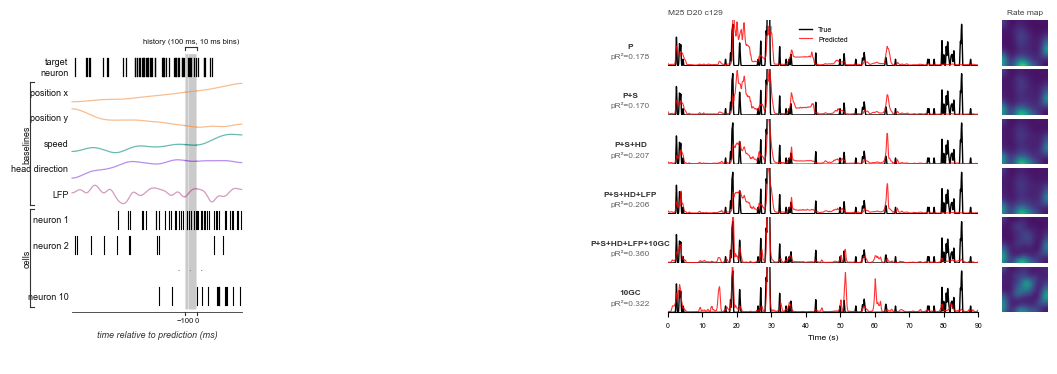

In [26]:
# ── Combined figure: schematic (REAL DATA) + prediction traces + rate maps ─────
# Requires cell 2 (data loading) to have been run first.
from scipy.ndimage import gaussian_filter, gaussian_filter1d
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

out_dir = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'
TIME_BS = time_bs   # ms per bin (50 ms)

# ── Parameters ─────────────────────────────────────────────────────────────────
PRE_MS    = 1000; HIST_MS = 100; POST_MS = 400; TOTAL_MS = 1500; N_BINS = 10
COV_SHOW  = [2, 4, 6]   # indices into cov_gc_ids: first two = neuron 1/2, last = neuron N
N_BINS_2D = 20           # spatial bins per axis for rate map
SIGMA_2D  = 1.5          # Gaussian smoothing (bins) for rate map
TRACE_FRAC = 0.78        # fraction of right column used for traces (rest = rate maps)

# ── Layout constants ───────────────────────────────────────────────────────────
TX0, TX1 = 0.26, 0.97;  TW = TX1 - TX0
MY0, MY1 = 0.16, 0.90;  MH = MY1 - MY0

def ms_to_x(ms): return TX0 + ms / TOTAL_MS * TW
HX0 = ms_to_x(PRE_MS);  HX1 = ms_to_x(PRE_MS + HIST_MS)
HW  = HX1 - HX0;        BW  = HW / N_BINS

MATRIX_BG = '#e0e0e0';  DIVIDER_C = '#aaaaaa'
SPIKE_COL = '#000000';  LABEL_COL = '#111111';  ANNO_COL = '#333333'

# ── Rate map helpers ───────────────────────────────────────────────────────────
def smooth_nan(arr, sigma=SIGMA_2D):
    mask   = np.isnan(arr)
    filled = arr.copy(); filled[mask] = 0.0
    s = gaussian_filter(filled.astype(float), sigma=sigma)
    w = gaussian_filter((~mask).astype(float), sigma=sigma)
    with np.errstate(invalid='ignore'):
        result = s / w
    result[w < 0.05] = np.nan
    return result

def make_rate_map(pred, px, py):
    x_bins = np.linspace(np.nanpercentile(px, 1), np.nanpercentile(px, 99), N_BINS_2D + 1)
    y_bins = np.linspace(np.nanpercentile(py, 1), np.nanpercentile(py, 99), N_BINS_2D + 1)
    spk, _, _ = np.histogram2d(px, py, bins=[x_bins, y_bins], weights=pred)
    occ, _, _ = np.histogram2d(px, py, bins=[x_bins, y_bins])
    with np.errstate(invalid='ignore', divide='ignore'):
        rm = np.where(occ > 2, spk / occ, np.nan)
    return smooth_nan(rm)

# ── Precompute rate maps (shared vmax from true map) ──────────────────────────
true_rm   = make_rate_map(y.astype(float), pos_x, pos_y)
vmax_rm   = float(np.nanpercentile(true_rm, 99))
rate_maps = {name: make_rate_map(predictions[name], pos_x, pos_y)
             for name in MODEL_SPECS}

# ── Window selection ───────────────────────────────────────────────────────────
TOTAL_BINS = int(TOTAL_MS / TIME_BS)
PRE_BINS   = int(PRE_MS   / TIME_BS)
MAX_BIN    = min(T, int(120_000 / TIME_BS))

if 'WIN0' in dir(): del WIN0

# Manual override: uncomment and set WIN0 to fix the window
# WIN0 = 800

if 'WIN0' not in dir():
    scores = np.array([
        y[t:t+TOTAL_BINS].sum()
        + 0.3 * cov_gc_mat[t:t+TOTAL_BINS, :4].sum()
        for t in range(MAX_BIN - TOTAL_BINS)
    ])
    WIN0 = int(np.argmax(scores))

WIN_S = WIN0 * TIME_BS / 1000
WIN_E = (WIN0 + TOTAL_BINS) * TIME_BS / 1000
print(f'Window: bins {WIN0}–{WIN0+TOTAL_BINS}  ({WIN_S:.2f}–{WIN_E:.2f} s)')
print(f'  target spikes in window: {y[WIN0:WIN0+TOTAL_BINS].sum():.0f}')

# ── Continuous signals: upsample 50 ms → 1 ms then smooth ────────────────────
def upsample_smooth(arr, t0, n_bins, sigma_ms=60):
    chunk = np.repeat(arr[t0:t0+n_bins].astype(float), TIME_BS)
    return gaussian_filter1d(chunk, sigma=sigma_ms)

def norm11(x):
    mn, mx = x.min(), x.max()
    return 2*(x-mn)/(mx-mn)-1 if mx > mn else np.zeros_like(x)

sc_sigs = {
    'pos_x': norm11(upsample_smooth(pos_x, WIN0, TOTAL_BINS)),
    'pos_y': norm11(upsample_smooth(pos_y, WIN0, TOTAL_BINS)),
    'speed': norm11(upsample_smooth(speed, WIN0, TOTAL_BINS)),
    'hd':    norm11(upsample_smooth(hd,    WIN0, TOTAL_BINS)),
    'lfp':   norm11(upsample_smooth(theta, WIN0, TOTAL_BINS, sigma_ms=30)),
}
sc_xs = np.linspace(TX0, TX1, TOTAL_MS)

# ── Real spike times (ms from window start) ───────────────────────────────────
def real_spikes_ms(cell_id, win_start_s, win_end_s):
    try:
        ts = clusters_OF[cell_id].restrict(nap.IntervalSet(win_start_s, win_end_s))
        return (np.array(ts.t) - win_start_s) * 1000
    except Exception:
        counts = np.array(tcs_time[cell_id]) if cell_id in tcs_time else np.zeros(T)
        out = []
        for i, cnt in enumerate(counts[WIN0:WIN0+TOTAL_BINS]):
            for k in range(max(0, int(cnt))):
                out.append((i + (k + 0.5) / max(int(cnt), 1)) * TIME_BS)
        return np.array(out)

sc_tgt_ms = real_spikes_ms(TARGET_ID, WIN_S, WIN_E)
sc_cells  = {k: real_spikes_ms(cov_gc_ids[k], WIN_S, WIN_E) for k in COV_SHOW}

# ── Row definitions ────────────────────────────────────────────────────────────
SROW_DEFS = [
    dict(label='target\nneuron', sig='spikes_tgt'),
    dict(label='position x',     sig='continuous', key='pos_x', color='#f4a261'),
    dict(label='position y',     sig='continuous', key='pos_y', color='#f4a261'),
    dict(label='speed',          sig='continuous', key='speed', color='#2a9d8f'),
    dict(label='head direction', sig='continuous', key='hd',    color='#9b5de5'),
    dict(label='LFP',            sig='continuous', key='lfp',   color='#c56fa4'),
    dict(label='neuron 1',       sig='spikes_cov', idx=COV_SHOW[0]),
    dict(label='neuron 2',       sig='spikes_cov', idx=COV_SHOW[1]),
    dict(label='',               sig='dots'),
    dict(label=f'neuron {N_COV}', sig='spikes_cov', idx=COV_SHOW[2]),
]
N_SROWS = len(SROW_DEFS)
SROW_H  = MH / N_SROWS
sry = lambda r: MY1 - (r + 0.5) * SROW_H
srt = lambda r: MY1 - r * SROW_H
srb = lambda r: MY1 - (r + 1) * SROW_H

# ── Prediction traces ──────────────────────────────────────────────────────────
DISP_SECS = 90
DISP_BINS = int(DISP_SECS * 1000 / TIME_BS)
SIG_BINS  = 10

smooth  = lambda x: gaussian_filter1d(x.astype(float), sigma=SIG_BINS)
y_sm    = smooth(y[:DISP_BINS])
t_disp  = np.arange(DISP_BINS) * TIME_BS / 1000
pred_sm = {n: smooth(predictions[n][:DISP_BINS]) for n in MODEL_SPECS}
y_max   = float(np.nanpercentile(
    np.concatenate([y_sm] + list(pred_sm.values())), 99)) * 1.15

N_MODELS = len(MODEL_SPECS)

# ── Figure layout ──────────────────────────────────────────────────────────────
GS_LEFT = 0.02; GS_RIGHT = 0.98; GS_TOP = 0.94; GS_BOT = 0.08

fig = plt.figure(figsize=(11, 4))
gs_out = gridspec.GridSpec(1, 3, figure=fig,
                            width_ratios=[3, 5, 5],
                            left=GS_LEFT, right=GS_RIGHT,
                            top=GS_TOP, bottom=GS_BOT, wspace=0.03)

# ── Left: schematic ───────────────────────────────────────────────────────────
ax_s = fig.add_subplot(gs_out[0])
ax_s.set_xlim(0, 1);  ax_s.set_ylim(0, 1);  ax_s.axis('off')

ax_s.add_patch(Rectangle((HX0, MY0), HW, MH,
                           facecolor=MATRIX_BG, edgecolor='none', zorder=1))
for b in range(1, N_BINS):
    x = HX0 + b * BW
    ax_s.plot([x, x], [MY0, MY1], color=DIVIDER_C, lw=0.4, alpha=0.7, zorder=3)

for r, row in enumerate(SROW_DEFS):
    yc = sry(r);  amp = SROW_H * 0.36
    if row['sig'] == 'spikes_tgt':
        for t_ms in sc_tgt_ms:
            if 0 <= t_ms <= TOTAL_MS:
                ax_s.plot([ms_to_x(t_ms)] * 2, [yc - amp, yc + amp],
                          color=SPIKE_COL, lw=0.9, zorder=5)
    elif row['sig'] == 'continuous':
        arr = sc_sigs[row['key']];  col = row['color']
        ys  = yc + amp * arr
        mp  = sc_xs <= HX0
        mh  = (sc_xs >= HX0) & (sc_xs <= HX1)
        mo  = sc_xs >= HX1
        ax_s.plot(sc_xs[mp], ys[mp], color=col, lw=0.9, alpha=0.7, zorder=4)
        ax_s.plot(sc_xs[mh], ys[mh], color=col, lw=0.9,             zorder=4)
        ax_s.plot(sc_xs[mo], ys[mo], color=col, lw=0.9, alpha=0.7, zorder=4)
    elif row['sig'] == 'spikes_cov':
        for t_ms in sc_cells[row['idx']]:
            if 0 <= t_ms <= TOTAL_MS:
                ax_s.plot([ms_to_x(t_ms)] * 2, [yc - amp, yc + amp],
                          color=SPIKE_COL, lw=0.8, zorder=5)
    elif row['sig'] == 'dots':
        ax_s.text((HX0 + HX1) / 2, yc, '·  ·  ·',
                  ha='center', va='center', fontsize=9, color='#888888', zorder=5)
    if row['label']:
        ax_s.text(TX0 - 0.016, yc, row['label'],
                  ha='right', va='center', fontsize=6.5, color=LABEL_COL)

def draw_br(x_bar, y_top, y_bot, label):
    x_bar-=0.1
    xw = x_bar + 0.015;  ym = (y_top + y_bot) / 2;  pad = 0.005
    for pts in [([x_bar, x_bar], [y_bot+pad, y_top-pad]),
                ([x_bar,    xw], [y_top-pad, y_top-pad]),
                ([x_bar,    xw], [y_bot+pad, y_bot+pad])]:
        ax_s.plot(*pts, color=ANNO_COL, lw=0.8, zorder=6)
    ax_s.text(x_bar - 0.014, ym, label,
              ha='center', va='center', fontsize=6.5, color=LABEL_COL, rotation=90)

BRX = TX0 - 0.075
draw_br(BRX, srt(1), srb(5), 'baselines')
draw_br(BRX, srt(6), srb(9), 'cells')

AY = MY0 - 0.010
ax_s.plot([TX0, TX1], [AY, AY], color=ANNO_COL, lw=0.6)
for ms_tick, lbl in [(PRE_MS, f'−{HIST_MS}'), (PRE_MS + HIST_MS, '0')]:
    xp = ms_to_x(ms_tick)
    ax_s.plot([xp, xp], [AY, AY - 0.007], color=ANNO_COL, lw=0.8)
    ax_s.text(xp, AY - 0.014, lbl, ha='center', va='top', fontsize=5.5, color=LABEL_COL)
ax_s.text((TX0 + TX1) / 2, AY - 0.052, 'time relative to prediction (ms)',
          ha='center', va='top', fontsize=6.5, fontstyle='italic', color=ANNO_COL)

hy = MY1 + 0.022
ax_s.plot([HX0, HX1], [hy, hy], color=ANNO_COL, lw=0.8)
ax_s.plot([HX0, HX0], [hy - 0.008, hy], color=ANNO_COL, lw=0.8)
ax_s.plot([HX1, HX1], [hy - 0.008, hy], color=ANNO_COL, lw=0.8)
ax_s.text((HX0 + HX1) / 2, hy + 0.009, f'history ({HIST_MS} ms, {N_BINS} ms bins)',
          ha='center', va='bottom', fontsize=5.5, color=LABEL_COL)

# ── Right column: split into traces (left) and rate maps (right) ──────────────
AY_fig   = GS_BOT + AY * (GS_TOP - GS_BOT)
right_bb = gs_out[2].get_position(fig)

trace_right = right_bb.x0 + (right_bb.x1 - right_bb.x0) * TRACE_FRAC
rm_left     = trace_right + 0.005

gs_pred = gridspec.GridSpec(N_MODELS, 1,
                             left=right_bb.x0, right=trace_right,
                             top=GS_TOP, bottom=AY_fig, hspace=0.08)

gs_rm   = gridspec.GridSpec(N_MODELS, 1,
                             left=rm_left, right=right_bb.x1,
                             top=GS_TOP, bottom=AY_fig, hspace=0.08)

for i, (name, _) in enumerate(MODEL_SPECS.items()):
    # ── Prediction trace ───────────────────────────────────────────────────────
    ax_p = fig.add_subplot(gs_pred[i])
    if i==0:
        ax_p.axvspan(WIN_S, WIN_E, ymin=np.max(y_sm), ymax=np.max(y_sm)*1.1, color='black', alpha=0.25, zorder=0)
    ax_p.plot(t_disp, y_sm,          color='black', lw=1.0)
    ax_p.plot(t_disp, pred_sm[name], color='red',   lw=0.8, alpha=0.8)
    ax_p.set_ylim(0, y_max);  ax_p.set_xlim(0, DISP_SECS)
    ax_p.set_yticks([])
    ax_p.spines[['top', 'right', 'left']].set_visible(False)
    ax_p.text(-0.12, 0.5, name,
              transform=ax_p.transAxes, fontsize=6, va='top',
              color='#333333', fontweight='bold', ha='center')
    ax_p.text(-0.12, 0.3, f'pR²={pr2_vals[name]:.3f}',
              transform=ax_p.transAxes, fontsize=6, va='top',
              ha='center', color='#666666')
    if i < N_MODELS - 1:
        ax_p.spines['bottom'].set_visible(False)
        ax_p.tick_params(bottom=False, labelbottom=False)
    else:
        ax_p.set_xlabel('Time (s)', fontsize=6)
        ax_p.tick_params(labelsize=5)
    if i == 0:
        ax_p.legend(
            handles=[Line2D([0],[0], color='black', lw=1.0, label='True'),
                     Line2D([0],[0], color='red',   lw=0.8, alpha=0.8, label='Predicted')],
            fontsize=5, loc='upper center', frameon=False)
        ax_p.set_title(f'M{MOUSE} D{DAY} c{TARGET_ID}', fontsize=6, pad=4,
                       loc='left', color='#444444')

    # ── Rate map ───────────────────────────────────────────────────────────────
    ax_rm = fig.add_subplot(gs_rm[i])
    ax_rm.imshow(rate_maps[name].T, origin='lower', aspect='equal',
                 cmap='viridis', vmin=0, vmax=vmax_rm)
    ax_rm.axis('off')
    if i == 0:
        ax_rm.set_title('Rate map', fontsize=6, pad=4, color='#444444')

fig.savefig(os.path.join(out_dir, 'xgboost_schematic_combined_real.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()
